In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
#from models.CNN_MLPlayers import CNNWithSizeMLPlayers
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix
from engine.data_setup import setup_datasets

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict

from loss_fn.focal_loss import FocalLoss
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 8078
Dataset setup complete.


In [9]:
num_classes = len(classes)
num_classes

10

In [3]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 858
1 Brassica napus 800
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 800
5 Hieracium umbellatum 800
6 Hypochaeris radicata 800
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [4]:

print("\nTest set class distribution:")
for k in sorted(test_counts):
    print(k, idx_to_class[int(k)], test_counts[k])


Test set class distribution:
0 Bellis perennis 142
1 Brassica napus 200
2 Capsella bursa-pastoris 183
3 Cichorium intybus 130
4 Crepis capillaris 200
5 Hieracium umbellatum 200
6 Hypochaeris radicata 200
7 Sonchus arvensis 334
8 Tragopogon pratensis 166
9 Tussilago farfara 167


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Performance metric
recall_metric = MulticlassRecall(num_classes=num_classes, average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=num_classes, average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


## Base Model (Erik's) & Excluding missing size

In [ ]:
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [13]:
BATCHSIZE = 32
EPOCHS = 20

history, test_loader = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,test_dataset=test_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=0
)

100%|██████████| 253/253 [00:25<00:00, 10.10it/s]


Epoch 1/20 | Train Loss: 0.0428, Train Acc: 0.9854


100%|██████████| 253/253 [00:23<00:00, 10.88it/s]


Epoch 2/20 | Train Loss: 0.0223, Train Acc: 0.9938


100%|██████████| 253/253 [00:23<00:00, 10.98it/s]


...

Epoch 18/20 | Train Loss: 0.0112, Train Acc: 0.9958


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 19/20 | Train Loss: 0.0206, Train Acc: 0.9926


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 20/20 | Train Loss: 0.0145, Train Acc: 0.9959



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.536622047424316
Mean of batch means: 0.8102777014013196
Mean of batch stds: 0.9024200390596859

Test Accuracy: 0.7680
Test Recall per class:
Class 0 (Bellis perennis): 0.3521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9846
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.5050
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9458
Class 9 (Tussilago farfara): 0.9940


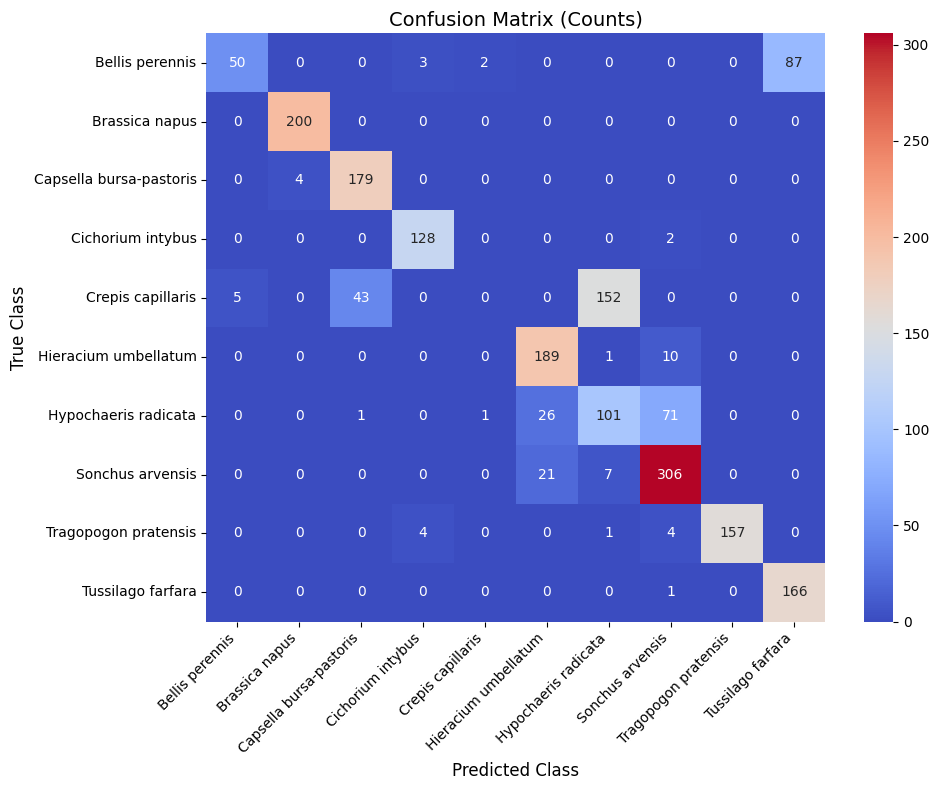

In [14]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_trained_models/base_model.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)